       fecha  ventas  precio   publicidad  promocion mes
0 2016-01-01       8    1000  1232.549717          0   1
1 2016-02-01       9    1000  2282.006274          0   2
2 2016-03-01      18    1000  2730.615908          0   3
3 2016-04-01       6    1000  1415.365877          1   4
4 2016-05-01       2    1000  1010.861444          1   5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       120 non-null    datetime64[ns]
 1   ventas      120 non-null    int64         
 2   precio      120 non-null    int64         
 3   publicidad  120 non-null    float64       
 4   promocion   120 non-null    int64         
 5   mes         120 non-null    category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(3)
memory usage: 5.3 KB
None


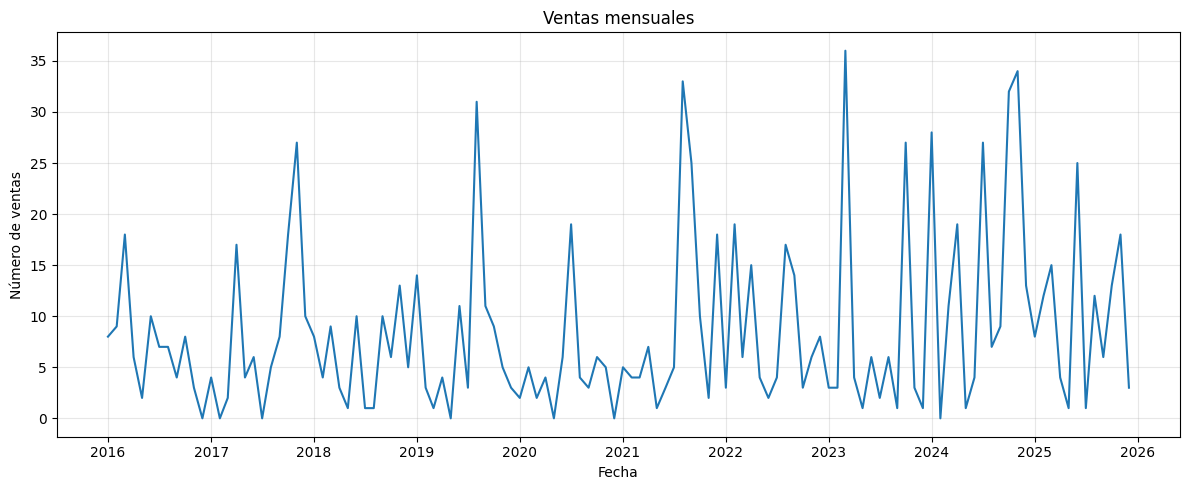

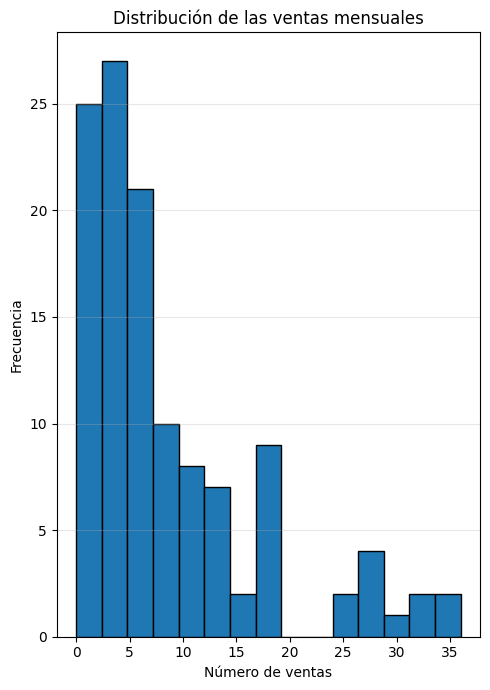


Estadísticas descriptivas:
                     fecha      ventas  precio   publicidad   promocion
count                  120  120.000000   120.0   120.000000  120.000000
mean   2020-12-15 18:00:00    8.491667  1000.0  1652.077143    0.341667
min    2016-01-01 00:00:00    0.000000  1000.0   368.353923    0.000000
25%    2018-06-23 12:00:00    3.000000  1000.0  1045.957977    0.000000
50%    2020-12-16 12:00:00    6.000000  1000.0  1406.097120    0.000000
75%    2023-06-08 12:00:00   11.000000  1000.0  2049.910505    1.000000
max    2025-12-01 00:00:00   36.000000  1000.0  5437.346146    1.000000
std                    NaN    8.386660     0.0   942.289210    0.476257

Media de ventas: 8.4917
Varianza de ventas: 70.3361
Razón varianza/media: 8.283


In [55]:
# ==========================================================
# Maestría en Ciencia y Análisis de Datos
# Universidad Mayor de San Andrés
# ----------------------------------------------------------
#    Modelos lineales y modelos lineales generalizados
# ----------------------------------------------------------
#        Rolando Gonzales Martinez, Julio 2026
# ==========================================================
#     MODELO POISSON Y EVALUACIÓN DE SOBREDISPERSIÓN
# ==========================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ==========================================================
# Importar la base de datos
# ==========================================================

url = "https://raw.githubusercontent.com/rogon666/UMSA/refs/heads/main/2026/MLMLG_2026/datos/ventas_preciofijo.csv"

data = pd.read_csv(url)

# Convertir fecha a formato datetime
data["fecha"] = pd.to_datetime(data["fecha"])

# Tratar el mes como variable categórica
data["mes"] = data["mes"].astype("category")

print(data.head())
print(data.info())


# ==========================================================
# Gráficos de ventas mensuales
# ==========================================================

plt.figure(figsize=(12, 5))
plt.plot(
    data["fecha"],
    data["ventas"],
    linewidth=1.5
)

plt.title("Ventas mensuales")
plt.xlabel("Fecha")
plt.ylabel("Número de ventas")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 7))

plt.hist(
    data["ventas"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribución de las ventas mensuales")
plt.xlabel("Número de ventas")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================================
# Estadísticas descriptivas
# ==========================================================

print("\nEstadísticas descriptivas:")
print(data.describe())

media_ventas = data["ventas"].mean()
varianza_ventas = data["ventas"].var()

razon_var_media = varianza_ventas / media_ventas

print("\nMedia de ventas:", round(media_ventas, 4))
print("Varianza de ventas:", round(varianza_ventas, 4))
print(
    "Razón varianza/media:",
    round(razon_var_media, 4)
)

# Una razón considerablemente mayor que 1 es una primera
# evidencia descriptiva de sobredispersión.


In [56]:
# ==========================================================
# Estimar modelo Poisson
# ==========================================================

formula = (
    "ventas ~ publicidad + promocion + C(mes)"
)

modelo_poisson = smf.glm(
    formula=formula,
    data=data,
    family=sm.families.Poisson()
).fit()

print("\nResultados del modelo Poisson:")
print(modelo_poisson.summary())


Resultados del modelo Poisson:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 ventas   No. Observations:                  120
Model:                            GLM   Df Residuals:                      106
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -334.14
Date:                Fri, 24 Jul 2026   Deviance:                       253.67
Time:                        16:55:57   Pearson chi2:                     260.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9938
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       

In [58]:
# ==========================================================
# Diagnóstico de sobredispersión
# ==========================================================

# Estadístico de dispersión basado en Pearson:
#
# phi = suma(residuos de Pearson^2) / grados de libertad

dispersion_pearson = (
    modelo_poisson.pearson_chi2
    / modelo_poisson.df_resid
)

# Estadístico basado en la deviance
dispersion_deviance = (
    modelo_poisson.deviance
    / modelo_poisson.df_resid
)

print("\nDiagnóstico de sobredispersión")
print(
    "Dispersión de Pearson:",
    round(dispersion_pearson, 4)
)

print(
    "Deviance / grados de libertad:",
    round(dispersion_deviance, 4)
)

if dispersion_pearson > 1.5:
    print(
        "\nExiste evidencia importante de sobredispersión."
    )
elif dispersion_pearson > 1:
    print(
        "\nExiste evidencia moderada de sobredispersión."
    )
else:
    print(
        "\nNo existe evidencia de sobredispersión."
    )


Diagnóstico de sobredispersión
Dispersión de Pearson: 2.4521
Deviance / grados de libertad: 2.3931

Existe evidencia importante de sobredispersión.


In [59]:
# ==========================================================
# 5. Prueba auxiliar de Cameron-Trivedi
# ==========================================================

# Bajo Poisson:
#
# Var(Y|X) = mu
#
# Bajo una alternativa NB2:
#
# Var(Y|X) = mu + alpha*mu^2
#
# Se estima la regresión auxiliar:
#
# ((y - mu)^2 - y) / mu = alpha*mu + error
#
# H0: alpha = 0
# H1: alpha > 0

mu_poisson = modelo_poisson.fittedvalues

variable_auxiliar = (
    ((data["ventas"] - mu_poisson) ** 2 - data["ventas"])
    / mu_poisson
)

regresor_auxiliar = mu_poisson

prueba_dispersion = sm.OLS(
    variable_auxiliar,
    regresor_auxiliar
).fit()

print("\nPrueba auxiliar de Cameron-Trivedi:")
print(prueba_dispersion.summary())

alpha_estimado = prueba_dispersion.params.iloc[0]
p_value_alpha = prueba_dispersion.pvalues.iloc[0]

print(
    "\nAlpha auxiliar estimado:",
    round(alpha_estimado, 4)
)

print(
    "Valor-p de la prueba:",
    round(p_value_alpha, 4)
)

if p_value_alpha < 0.05 and alpha_estimado > 0:
    print(
        "Se rechaza H0: existe sobredispersión."
    )
else:
    print(
        "No se rechaza H0 de equidispersión."
    )


Prueba auxiliar de Cameron-Trivedi:
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.051
Model:                            OLS   Adj. R-squared (uncentered):              0.043
Method:                 Least Squares   F-statistic:                              6.330
Date:                Fri, 24 Jul 2026   Prob (F-statistic):                      0.0132
Time:                        16:56:26   Log-Likelihood:                         -356.45
No. Observations:                 120   AIC:                                      714.9
Df Residuals:                     119   BIC:                                      717.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
----